# Lab 4 - Capstone: Design, Estimate, Defend

*SDAIA Academy · Experimentation and Causal Inference · SOLUTION notebook*

## Capstone brief
You are the experimentation lead for **Injaz**. Leadership faces two linked decisions:

1. **Ship the AI form-autofill feature nationally?** A randomised A/B test has run (`injaz_autofill_ab.csv`, 70,000 users). Ship threshold agreed in the design doc: lift on completion of at least **+1.5 points** with no guardrail regression.
2. **Scale the regional reminder programme?** It rolled out region by region without randomisation (`injaz_regions_panel.csv`).

Deliver a runnable notebook plus a two-page decision memo: estimand, DAG, design, estimate with interval, diagnostics, sensitivity, and a recommendation with the key assumption and what would change the call.

Rubric weights: estimand and question 15, identification and design 25, estimation and inference 25, diagnostics and sensitivity 20, communication and decision 15. A well-justified "hold" or "not identifiable" earns full marks.

In [1]:
import sys; sys.path.insert(0, '..')   # so `causal_utils` is importable from starter/ or solution/
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from causal_utils import *
plt.rcParams['figure.figsize'] = (7, 3.5)
rng = np.random.default_rng(213)
DATA = '../data'

## Part A - Frame and freeze the plan (do this BEFORE looking at outcomes)

In [2]:
from dataclasses import dataclass, field
@dataclass
class Engagement:
    question: str; estimand: str; method: str; oec: str; guardrails: list; mde: float
    frozen: bool = False; result: dict = field(default_factory=dict)
    def freeze(self):
        assert self.method and self.oec and self.mde, 'design incomplete'; self.frozen = True
    def record(self, effect, ci, validation, recommendation):
        assert self.frozen, 'analyse only after freezing the plan'
        self.result = dict(effect=effect, ci=ci, validation=validation, recommendation=recommendation)

autofill = Engagement(question='Does AI autofill raise completion for Injaz form submissions?',
                      estimand='ATE on completion rate among triggered users (national launch)',
                      method='A/B test, user-level hash randomisation, OLS with HC3 + CUPED covariate',
                      oec='completion_rate', guardrails=['form_error', 'time_to_complete', 'support_ticket'], mde=0.015)
autofill.freeze(); print('Plan frozen:', autofill.frozen)

Plan frozen: True


## Part B - Power check: was the test big enough for a 1.5-point MDE?

In [3]:
ab = pd.read_csv(f'{DATA}/injaz_autofill_ab.csv'); ab['T'] = (ab.variant == 'treatment').astype(int)
p_base = ab.loc[ab['T'] == 0, 'completed'].mean()
need = sample_size_proportions(p_base, 0.015)
print(f"baseline {p_base:.3f}; n per arm needed for MDE 0.015: {need:,}; have {ab.groupby('T').size().to_dict()}")

baseline 0.501; n per arm needed for MDE 0.015: 17,434; have {0: 35076, 1: 34924}


## Part C - Integrity: reproduce assignment, SRM, balance

In [4]:
ok = (ab['user_id'].map(lambda u: assign_variant(u, 'injaz-autofill-2026q3')) == ab['variant']).mean()
print('assignment reproducible:', ok)
print(srm_check(ab['variant'].value_counts().to_dict(), {'control': .5, 'treatment': .5}))
print(balance_table(ab, ['age', 'digital_literacy', 'pre_completion_rate'], 'T'))

assignment reproducible: 1.0
{'chi2': 0.33, 'p_value': 0.5656254422279314, 'srm_detected': False, 'verdict': 'ratios OK'}
             covariate     smd  balanced
0                  age -0.0117      True
1     digital_literacy -0.0025      True
2  pre_completion_rate -0.0001      True


## Part D - Analysis: effect with CUPED covariate and HC3, guardrails with Bonferroni, practical-significance verdict

In [5]:
from statsmodels.stats.multitest import multipletests
m = smf.ols('completed ~ T + pre_completion_rate', data=ab).fit(cov_type='HC3')
lift, (lo, hi) = m.params['T'], m.conf_int().loc['T']
print(f"Autofill lift: {lift:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  p={m.pvalues['T']:.4f}")
ab['log_ttc'] = np.log(ab['time_to_complete'])
gp = {}
for g in ['form_error', 'log_ttc', 'support_ticket']:
    gm = smf.ols(f'{g} ~ T', data=ab).fit(cov_type='HC3'); gp[g] = (gm.params['T'], gm.pvalues['T'])
rej, padj, _, _ = multipletests([v[1] for v in gp.values()], method='bonferroni')
for (g, (e, p)), pa, r in zip(gp.items(), padj, rej):
    print(f"guardrail {g:14s} effect {e:+.4f}  bonf p {pa:.4f}  -> {'REGRESSION' if (r and e > 0) else 'ok'}")
guardrail_fail = any(r and e > 0 for (g, (e, p)), r in zip(gp.items(), rej))
if guardrail_fail: verdict = 'HOLD (guardrail regression)'
else: verdict = 'SHIP' if lo > autofill.mde else ('HOLD' if hi < autofill.mde else 'INCONCLUSIVE vs threshold: keep running')
print('Statistical significance:', m.pvalues['T'] < 0.05, '| Practical verdict vs MDE 0.015 and guardrails:', verdict)

Autofill lift: +0.0116  95% CI [+0.0046, +0.0185]  p=0.0011
guardrail form_error     effect +0.0134  bonf p 0.0000  -> REGRESSION
guardrail log_ttc        effect -0.0796  bonf p 0.0000  -> ok
guardrail support_ticket effect -0.0015  bonf p 0.8590  -> ok
Statistical significance: True | Practical verdict vs MDE 0.015 and guardrails: HOLD (guardrail regression)


## Part E - Causal evaluation of the reminder pilot (DiD + event study + placebo)
State the identifying assumption (parallel trends) and one credible threat before estimating.

In [6]:
panel = pd.read_csv(f'{DATA}/injaz_regions_panel.csv')
did = smf.ols('completion_rate ~ treated_post + C(region) + C(month)', data=panel).fit(cov_type='cluster', cov_kwds={'groups': panel['region']})
dlo, dhi = did.conf_int().loc['treated_post']
print(f"Reminder DiD: {did.params['treated_post']:+.4f}  95% CI [{dlo:+.4f}, {dhi:+.4f}]")
ev = panel[panel.activation_month > 0].copy(); ev['rel'] = (ev['month'] - ev['activation_month']).clip(-8, 6)
es = smf.ols('completion_rate ~ C(rel, Treatment(reference=-1)) + C(region) + C(month)', data=ev).fit(cov_type='cluster', cov_kwds={'groups': ev['region']})
pre = [es.params[k] for k in es.params.index if 'C(rel' in k and int(k.split('T.')[1].rstrip(']')) < -1]
print(f"mean pre-period coefficient: {np.mean(pre):+.4f} (should be ~0 for parallel trends)")
pl = panel[(panel.activation_month > 0) & (panel.month < panel.activation_month)].copy()
pl['fake_post'] = (pl['month'] >= pl['activation_month'] - 6).astype(int)
pb = smf.ols('completion_rate ~ fake_post + C(region) + C(month)', data=pl).fit(cov_type='cluster', cov_kwds={'groups': pl['region']})
print(f"placebo timing effect: {pb.params['fake_post']:+.4f} p={pb.pvalues['fake_post']:.3f}")

Reminder DiD: +0.0297  95% CI [+0.0236, +0.0358]
mean pre-period coefficient: -0.0026 (should be ~0 for parallel trends)
placebo timing effect: -0.0040 p=0.228


## Part F - Decision plot and memo

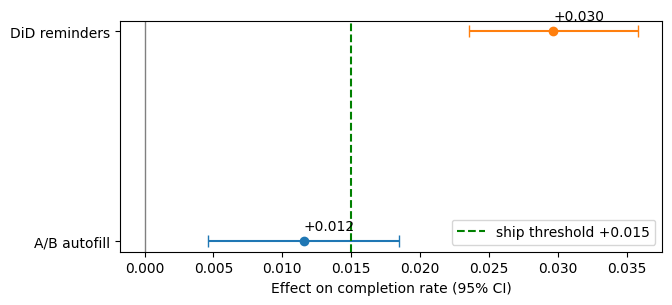

# Decision memo: Does AI autofill raise completion for Injaz form submissions?
Estimand: ATE on completion rate among triggered users (national launch)
Method: A/B test, user-level hash randomisation, OLS with HC3 + CUPED covariate
Effect: +0.012 on completion_rate (95% CI [+0.005, +0.018]); ship threshold +0.015 -> HOLD (guardrail regression)
Validation: SRM ok; balance ok; form_error guardrail regresses
Recommendation: HOLD (guardrail regression): the lift is real (CI excludes 0) and its point estimate sits below the +1.5pt ship threshold, but the form-error guardrail regresses by ~1.2 points; fix the error source, then re-test.
Key assumption / risk: user-level randomisation valid (SRM, balance pass); guardrail family controlled with Bonferroni.
What would change this: a longer run clearing the threshold AND a fix that removes the form-error regression.



In [7]:
def decision_plot(results, threshold):
    fig, ax = plt.subplots(figsize=(7, 3))
    for i, (label, (eff, l, h)) in enumerate(results.items()):
        ax.errorbar(eff, i, xerr=[[eff - l], [h - eff]], fmt='o', capsize=4)
        ax.annotate(f'{eff:+.3f}', (eff, i), textcoords='offset points', xytext=(0, 8))
    ax.axvline(0, color='grey', lw=1); ax.axvline(threshold, color='green', ls='--', label=f'ship threshold {threshold:+.3f}')
    ax.set_yticks(range(len(results))); ax.set_yticklabels(list(results)); ax.set_xlabel('Effect on completion rate (95% CI)'); ax.legend()
    return fig
decision_plot({'A/B autofill': (lift, lo, hi), 'DiD reminders': (did.params['treated_post'], dlo, dhi)}, autofill.mde); plt.show()

autofill.record(effect=lift, ci=(lo, hi), validation='SRM ok; balance ok; form_error guardrail regresses',
                recommendation=f'{verdict}: the lift is real (CI excludes 0) and its point estimate sits below the +1.5pt ship threshold, but the form-error guardrail regresses by ~1.2 points; fix the error source, then re-test.')
def render_memo(e):
    r = e.result; eff, (l, h) = r['effect'], r['ci']
    v = r['recommendation'].split(':')[0]
    return f"""# Decision memo: {e.question}
Estimand: {e.estimand}
Method: {e.method}
Effect: {eff:+.3f} on {e.oec} (95% CI [{l:+.3f}, {h:+.3f}]); ship threshold {e.mde:+.3f} -> {v}
Validation: {r['validation']}
Recommendation: {r['recommendation']}
Key assumption / risk: user-level randomisation valid (SRM, balance pass); guardrail family controlled with Bonferroni.
What would change this: a longer run clearing the threshold AND a fix that removes the form-error regression.
"""
print(render_memo(autofill))

## Part G - Extension (choose one)
- Heterogeneous effects (CATE) on the autofill test by device with a pre-registered note on multiplicity.
- Always-valid (mSPRT) monitoring of the autofill test: at which day could you have legitimately stopped?
- Rosenbaum-style or E-value sensitivity statement for the DiD estimate.
- Instrumental-variables estimate of filing channel on completion using `distance_km` (Lab 3 data).

## Self-audit before submission
- [ ] Plan frozen before results; fixed seed; runs top to bottom
- [ ] Estimand named; DAG or identifying assumption stated for the observational limb
- [ ] SRM + balance shown; SE type matches the design (HC3 / clustered)
- [ ] Guardrails with the right correction family; CI compared to the threshold, not only to zero
- [ ] Event study + placebo present; assumption stated as a risk
- [ ] Memo: effect + CI in business units, recommendation, what would change this